In [1]:
import os, re, math, random, json, collections
import urllib.request, ssl
import numpy as np
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

print("Environment ready")


Environment ready


In [2]:
def fetch_url_text(url, encoding="utf-8"):
    ctx = ssl.create_default_context()
    ctx.check_hostname = False
    ctx.verify_mode = ssl.CERT_NONE
    with urllib.request.urlopen(url, context=ctx) as r:
        data = r.read()
    try:
        return data.decode(encoding)
    except:
        for enc in ("utf-8", "utf-8-sig", "cp1252", "latin-1"):
            try:
                return data.decode(enc, errors="ignore")
            except:
                pass
        return data.decode("utf-8", errors="ignore")

def normalize_spaces(s: str):
    return "\n".join(line.strip() for line in s.splitlines())


In [3]:
USE_URLS = True

urls_A = [
    "https://www.gutenberg.org/ebooks/1342.txt.utf-8",
    "https://www.gutenberg.org/cache/epub/2701/pg2701.txt",
    "https://www.gutenberg.org/files/11/11-0.txt",
]

urls_B = [
    "https://irclogs.ubuntu.com/2024/04/19/%23ubuntu-desktop.txt",
    "https://irclogs.ubuntu.com/2024/04/19/%23ubuntu-next.txt",
    "https://irclogs.ubuntu.com/2024/04/19/%23ubuntu-bugs.txt",
]
print("Source config ready (toggle USE_URLS)")


Source config ready (toggle USE_URLS)


In [4]:
domainA_text, domainB_text = "", ""

if USE_URLS:
    domainA_text = "\n".join(fetch_url_text(u) for u in urls_A)
    domainB_text = "\n".join(fetch_url_text(u) for u in urls_B)
else:
    from google.colab import files
    def read_uploaded_txts(prefix="A"):
        print(f"Upload TXT files for domain {prefix}")
        uploaded = files.upload()
        texts = []
        for name, data in uploaded.items():
            if name.lower().endswith(".txt"):
                txt = data.decode("utf-8", errors="ignore")
                texts.append(txt)
                print(f" - {name}: {len(txt)} chars")
            else:
                print(f" ! Skipped non-txt: {name}")
        return "\n".join(texts)
    print("도메인 A 업로드 단계"); domainA_text = read_uploaded_txts("A")
    print("도메인 B 업로드 단계"); domainB_text = read_uploaded_txts("B")

domainA_text = normalize_spaces(domainA_text)
domainB_text = normalize_spaces(domainB_text)

print("Loaded texts")
print("A chars:", len(domainA_text), "| B chars:", len(domainB_text))
print("A sample:", domainA_text[:200].replace("\n"," ") + " ...")
print("B sample:", domainB_text[:200].replace("\n"," ") + " ...")


Loaded texts
A chars: 2126391 | B chars: 9669
A sample: ﻿The Project Gutenberg eBook of Pride and Prejudice  This ebook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restrictions what ...
B sample: === guiverc2 is now known as guiverc [08:00] <antithesis_> noobuntu is so LE bloated reeeeeeeeeeeeeeeeeeeeeeeeeeeeeee [11:31] <KGB-X> vala tags 27f5147 Rico Tzschichholz upstream/0.56.17 * Upstream ve ...


In [5]:
def normalize_text(s: str, lowercase=True):
    if lowercase:
        s = s.lower()
    s = re.sub(r'https?://\S+', '<url>', s)
    s = re.sub(r'\d+', '<num>', s)
    return s

def split_sentences(s: str):
    parts = re.split(r'[\.!\?\n]+', s)
    parts = [p.strip() for p in parts if p.strip()]
    return parts

def tokenize_sentence(sent: str):
    return re.findall(r'\w+|<url>|<num>|[^\w\s]', sent)

def build_corpus_tokens(raw_text: str, min_freq=2, lowercase=True):
    text = normalize_text(raw_text, lowercase=lowercase)
    sents = split_sentences(text)
    tokenized_sents = [tokenize_sentence(sent) for sent in sents]
    freq = collections.Counter(tok for sent in tokenized_sents for tok in sent)
    vocab = {tok for tok,c in freq.items() if c >= min_freq}
    vocab.update({'<unk>','<s>','</s>'})
    corpus = []
    for sent in tokenized_sents:
        sent2 = ['<s>'] + [tok if tok in vocab else '<unk>' for tok in sent] + ['</s>']
        corpus.append(sent2)
    return corpus, sorted(vocab)

corpusA, vocabA = build_corpus_tokens(domainA_text, min_freq=2, lowercase=True)
corpusB, vocabB = build_corpus_tokens(domainB_text, min_freq=2, lowercase=True)

print(f"A: {sum(len(s) for s in corpusA)} tokens in {len(corpusA)} sents, V={len(vocabA)}")
print(f"B: {sum(len(s) for s in corpusB)} tokens in {len(corpusB)} sents, V={len(vocabB)}")


A: 541215 tokens in 49685 sents, V=12105
B: 2414 tokens in 152 sents, V=208


In [6]:
def split_dataset(corpus, ratios=(0.8, 0.1, 0.1)):
    n = len(corpus)
    idx = np.arange(n)
    np.random.shuffle(idx)
    a = int(n*ratios[0]); b = a + int(n*ratios[1])
    train = [corpus[i] for i in idx[:a]]
    valid = [corpus[i] for i in idx[a:b]]
    test  = [corpus[i] for i in idx[b:]]
    return train, valid, test

A_train, A_valid, A_test = split_dataset(corpusA)
B_train, B_valid, B_test = split_dataset(corpusB)

print(f"A splits: train={len(A_train)}, valid={len(A_valid)}, test={len(A_test)}")
print(f"B splits: train={len(B_train)}, valid={len(B_valid)}, test={len(B_test)}")

A splits: train=39748, valid=4968, test=4969
B splits: train=121, valid=15, test=16


In [7]:
class BigramLM:
    def __init__(self, k=1.0, vocab=None):
        self.k = k
        self.vocab = list(vocab) if vocab is not None else None
        self.V = len(self.vocab) if self.vocab is not None else None
        self.unigram = collections.Counter()
        self.bigram = collections.Counter()
        self.context_totals = collections.Counter()
        self.idx = {w:i for i,w in enumerate(self.vocab)} if self.vocab else {}

    def fit(self, sentences):
        for sent in sentences:
            for i in range(1, len(sent)):
                w_prev, w = sent[i-1], sent[i]
                self.unigram[w_prev] += 1
                self.bigram[(w_prev, w)] += 1
                self.context_totals[w_prev] += 1

    def prob(self, w_prev, w):
        c = self.bigram[(w_prev, w)]
        total = self.context_totals[w_prev]
        return (c + self.k) / (total + self.k * self.V)

    def next_word_dist(self, w_prev):
        probs = np.array([self.prob(w_prev, w) for w in self.vocab], dtype=np.float64)
        probs /= probs.sum()
        return self.vocab, probs

    def sample_sentence(self, max_len=30):
        sent = ['<s>']
        for _ in range(max_len):
            vocab, p = self.next_word_dist(sent[-1])
            w = np.random.choice(vocab, p=p)
            sent.append(w)
            if w == '</s>':
                break
        return " ".join(tok for tok in sent[1:-1] if tok not in ['<s>'])

def build_vocab_union(vocabA, vocabB):
    s = set(vocabA) | set(vocabB)
    s.update({'<s>','</s>','<unk>'})
    return sorted(s)

V_union = build_vocab_union(vocabA, vocabB)
print("V_union size:", len(V_union))

k = 1.0
lmA = BigramLM(k=k, vocab=V_union)
lmB = BigramLM(k=k, vocab=V_union)
lmA.fit(A_train)
lmB.fit(B_train)
print("Trained Bigram LMs (A,B)")


V_union size: 12182
Trained Bigram LMs (A,B)


In [8]:
for name, lm in [("A", lmA), ("B", lmB)]:
    print(f"\n--- Samples from LM{name} ---")
    for i in range(5):
        print(f"{i+1}.", lm.sample_sentence())



--- Samples from LMA ---
1. brought jerked statements visions cain spin splashed gorgeous bottomless wraps pleasantry wisdom items grego devious withheld dint adamite legend gayer displays peddling frankly hackney actively never brimmed crown regulars
2. cabin multitudinously cruisers doubling pages rigged ridiculous is incapable shovel containing cheese possessing hasn recklessness disclosed extreme tis heroic nimble boisterous compliment alabama hilarious worthless tamely pays supposing northward
3. ceti plank consuming hedgehogs spokes cadence cables daughter mechanical dilated landing ensigns late dropping william junction robe rad jot depresses learned profane indolence basketed accessed failures chat transient compact
4. swung sooty intrude conceal doubled hell freckled flee canals truly advocate hurried willingly poky fool chains warranties abide profession tempted adequate repetition zones perils heard tattooed merchant rules nephew
5. craft ballasted boisterously abreast here

In [9]:
def corpus_logprob_and_count(lm: BigramLM, sentences):
    logp = 0.0
    count = 0
    for sent in sentences:
        for i in range(1, len(sent)):
            w_prev, w = sent[i-1], sent[i]
            if w_prev not in lm.idx: w_prev = '<unk>'
            if w not in lm.idx: w = '<unk>'
            p = lm.prob(w_prev, w)
            logp += math.log(p + 1e-12)
            count += 1
    return logp, count

def perplexity(lm: BigramLM, sentences):
    logp, n = corpus_logprob_and_count(lm, sentences)
    if n == 0:
        return float("inf")
    return math.exp(-logp / n)

def evaluate_all():
    results = {}
    results[("A->A", "valid")] = perplexity(lmA, A_valid)
    results[("A->A", "test")]  = perplexity(lmA, A_test)
    results[("B->B", "valid")] = perplexity(lmB, B_valid)
    results[("B->B", "test")]  = perplexity(lmB, B_test)
    results[("A->B", "valid")] = perplexity(lmA, B_valid)
    results[("A->B", "test")]  = perplexity(lmA, B_test)
    results[("B->A", "valid")] = perplexity(lmB, A_valid)
    results[("B->A", "test")]  = perplexity(lmB, A_test)
    return results

pp = evaluate_all()
print("Perplexity results:")
for k,v in pp.items():
    print(f"{k}: {v:.3f}")


Perplexity results:
('A->A', 'valid'): 1128.888
('A->A', 'test'): 1124.816
('B->B', 'valid'): 2021.527
('B->B', 'test'): 2354.505
('A->B', 'valid'): 4471.242
('A->B', 'test'): 3234.609
('B->A', 'valid'): 11244.539
('B->A', 'test'): 11265.029


In [10]:
from math import log2

def top_bigrams(counter, topn=20):
    return counter.most_common(topn)

def bigram_distribution_matrix(lm: BigramLM, vocab):
    V = len(vocab)
    M = np.zeros((V, V), dtype=np.float64)
    for i, u in enumerate(vocab):
        total = lm.context_totals[u]
        row = np.array([(lm.bigram[(u, w)] + lm.k) / (total + lm.k * V) for w in vocab], dtype=np.float64)
        row_sum = row.sum()
        if row_sum > 0:
            row /= row_sum
        M[i] = row
    return M

def js_divergence(p, q):
    m = 0.5*(p+q)
    eps = 1e-12
    kl_pm = np.sum(p * np.log((p+eps)/(m+eps)))
    kl_qm = np.sum(q * np.log((q+eps)/(m+eps)))
    return 0.5*(kl_pm + kl_qm)

print("\nTop-20 bigrams A (by count):")
for bg,c in top_bigrams(lmA.bigram, 20):
    print(bg, c)

print("\nTop-20 bigrams B (by count):")
for bg,c in top_bigrams(lmB.bigram, 20):
    print(bg, c)

Ma = bigram_distribution_matrix(lmA, lmA.vocab)
Mb = bigram_distribution_matrix(lmB, lmB.vocab)
row_js = [js_divergence(Ma[i], Mb[i]) for i in range(len(lmA.vocab))]
js_mean = float(np.mean(row_js))
print(f"\nMean row-wise JS divergence (A vs B): {js_mean:.6f}")



Top-20 bigrams A (by count):
(',', 'and') 3517
('<s>', '“') 2702
('<s>', '”') 2418
('’', 's') 2166
('of', 'the') 1947
('”', '</s>') 1919
('the', '</s>') 1656
('<s>', 'the') 1617
(',', '</s>') 1594
(';', 'and') 1308
('in', 'the') 1281
('<unk>', '</s>') 1035
('<unk>', ',') 974
(',', '”') 921
('<s>', '<unk>') 890
('<s>', 'and') 875
(',', 'the') 865
('to', 'the') 833
('<s>', 'but') 803
('and', '</s>') 741

Top-20 bigrams B (by count):
('<num>', ':') 53
('<s>', '[') 52
('[', '<num>') 52
(':', '<num>') 52
('<num>', ']') 52
('<unk>', '<unk>') 42
(']', '<') 37
('<unk>', '</s>') 20
('<s>', '<num>') 20
('<num>', '</s>') 18
('ubuntu', '-') 16
('<num>', '*') 16
('<url>', '</s>') 16
('-', 'desktop') 15
(']', '-') 15
('-', 'ubottu') 15
('ubottu', ':') 15
(':', '#') 15
('#', 'ubuntu') 15
('desktop', '-') 14

Mean row-wise JS divergence (A vs B): 0.000442


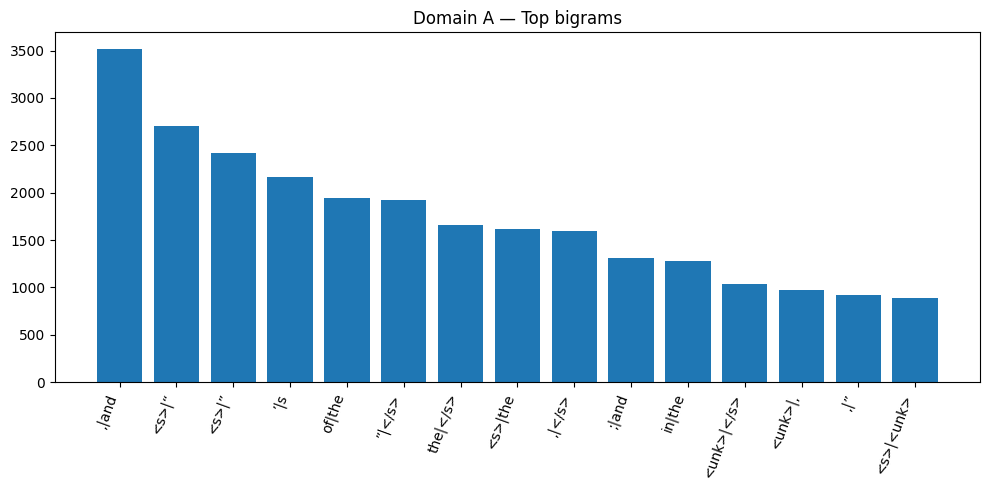

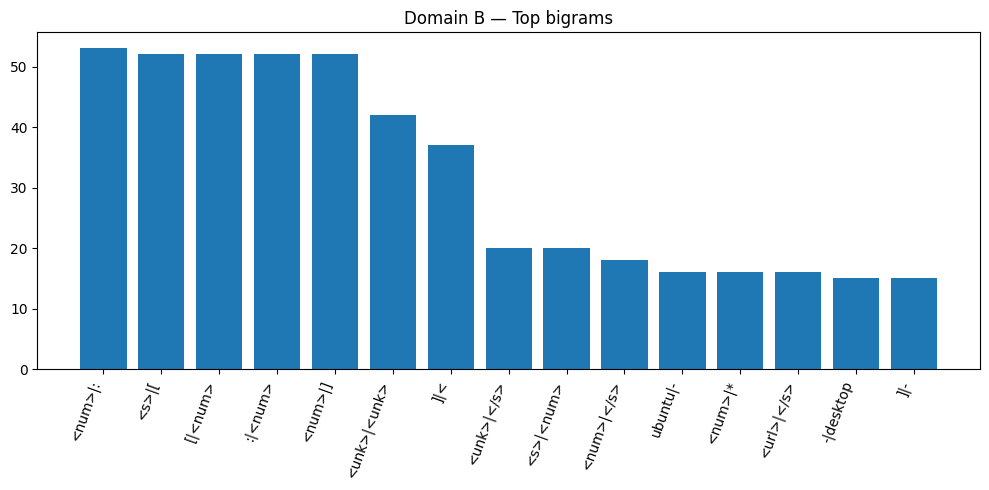

In [11]:
def plot_top_bigrams(counter, title="Top bigrams", topn=15):
    pairs = counter.most_common(topn)
    labels = [f"{u}|{w}" for (u,w),c in pairs]
    counts = [c for (_,c) in pairs]
    plt.figure(figsize=(10,5))
    plt.bar(range(len(counts)), counts)
    plt.xticks(range(len(counts)), labels, rotation=70, ha='right')
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_top_bigrams(lmA.bigram, "Domain A — Top bigrams", topn=15)
plot_top_bigrams(lmB.bigram, "Domain B — Top bigrams", topn=15)


In [12]:
os.makedirs("outputs", exist_ok=True)

with open("outputs/perplexity.json", "w", encoding="utf-8") as f:
    json.dump({f"{k[0]}_{k[1]}": float(v) for k,v in pp.items()}, f, ensure_ascii=False, indent=2)

def save_top_bigrams(counter, path, topn=100):
    import csv
    with open(path, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["prev","word","count"])
        for (u,v),c in counter.most_common(topn):
            w.writerow([u,v,c])

save_top_bigrams(lmA.bigram, "outputs/top_bigrams_A.csv", topn=100)
save_top_bigrams(lmB.bigram, "outputs/top_bigrams_B.csv", topn=100)

with open("outputs/js_score.txt", "w", encoding="utf-8") as f:
    f.write(f"Mean row-wise JS divergence (A vs B): {js_mean:.6f}\n")

print("Saved files:", os.listdir("outputs"))


Saved files: ['perplexity.json', 'top_bigrams_B.csv', 'top_bigrams_A.csv', 'js_score.txt']


In [13]:
summary = {
    "data": {
        "A": {"num_sents": len(corpusA), "num_tokens": int(sum(len(s) for s in corpusA)), "V": len(vocabA)},
        "B": {"num_sents": len(corpusB), "num_tokens": int(sum(len(s) for s in corpusB)), "V": len(vocabB)},
    },
    "model": {"type": "Bigram LM", "smoothing": f"add-k (k={k})", "vocab": "union(A,B)", "boundary_tokens": ["<s>","</s>"], "unk": "<unk>"},
    "perplexity": {f"{k[0]}_{k[1]}": float(v) for k,v in pp.items()},
    "js_divergence_mean": js_mean,
    "notes": [
        "전처리: 소문자화, URL-><url>, 숫자-><num>, 희귀단어<unk>",
        "공정비교: 동일 전처리/스무딩/분할",
        "추가 가능: Tri-gram/KN-smoothing/Subword/더 큰 코퍼스",
    ]
}
print(json.dumps(summary, ensure_ascii=False, indent=2))


{
  "data": {
    "A": {
      "num_sents": 49685,
      "num_tokens": 541215,
      "V": 12105
    },
    "B": {
      "num_sents": 152,
      "num_tokens": 2414,
      "V": 208
    }
  },
  "model": {
    "type": "Bigram LM",
    "smoothing": "add-k (k=('B->A', 'test'))",
    "vocab": "union(A,B)",
    "boundary_tokens": [
      "<s>",
      "</s>"
    ],
    "unk": "<unk>"
  },
  "perplexity": {
    "A->A_valid": 1128.8883144281751,
    "A->A_test": 1124.8163975406205,
    "B->B_valid": 2021.5270020483138,
    "B->B_test": 2354.5051332213357,
    "A->B_valid": 4471.242210018056,
    "A->B_test": 3234.609249887608,
    "B->A_valid": 11244.538979145524,
    "B->A_test": 11265.028639911348
  },
  "js_divergence_mean": 0.00044161218906767317,
  "notes": [
    "전처리: 소문자화, URL-><url>, 숫자-><num>, 희귀단어<unk>",
    "공정비교: 동일 전처리/스무딩/분할",
    "추가 가능: Tri-gram/KN-smoothing/Subword/더 큰 코퍼스"
  ]
}
